<a href="https://colab.research.google.com/github/tawaqalt/Projects/blob/main/Customer_Purchase_Analysis_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Relevant Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Reading the Dataset

In [ ]:
df = pd.read_csv('/content/purchase_data (1).csv')

# Data Pre-Processing

In [ ]:
#displaying the first ten rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01/12/2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/12/2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01/12/2010 08:34,1.69,13047.0,United Kingdom


In [ ]:
#checking the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
#checking the shape
df.shape

(541909, 8)

In [ ]:
#checking for the columns description
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
#checking for null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#checking for duplicates
df.duplicated().sum()

5268

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


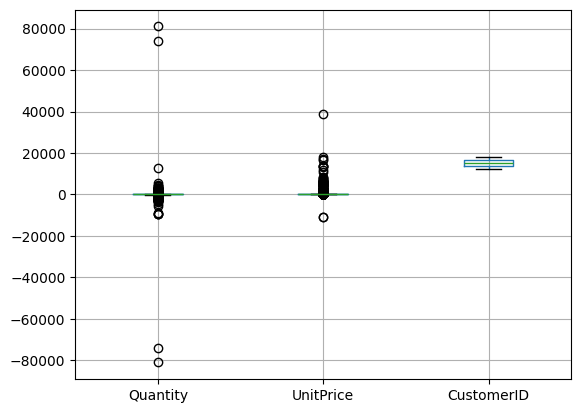

In [ ]:
#Visualizing the box plot distribution for all variables in the dataset
df.boxplot()
plt.show()

In [ ]:
#checking for outliers
def detect_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df < lower_bound) | (df> upper_bound)]
    return outliers

for col in df.select_dtypes(include=np.number).columns:
    outliers = detect_outliers_iqr(df[col])
    print(f"Outliers in {col}:")
    print(outliers)
    print("-" * 20)

Outliers in Quantity:
9         32
26        24
27        24
30        24
31        48
          ..
541876    24
541882    24
541883    25
541891    24
541892    24
Name: Quantity, Length: 58619, dtype: int64
--------------------
Outliers in UnitPrice:
16         9.95
45        18.00
65        10.95
141       27.50
151       14.95
          ...  
541768    18.00
541786    11.95
541831     8.50
541849     9.95
541892     8.95
Name: UnitPrice, Length: 39627, dtype: float64
--------------------
Outliers in CustomerID:
Series([], Name: CustomerID, dtype: float64)
--------------------


In [ ]:
df.dropna(inplace=True)

In [ ]:
# Converting InvoiceDate to datetime, specifying the correct format with dayfirst=True
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M', dayfirst=True)

#  To Calculate the revenue per transaction
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Removing cancelled orders (those starting with 'C') and negative quantities
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Revenue'] > 0]

# to get the monthly aggregations, it needs to be caluclated using the formular below
monthly_data = df.groupby(df['InvoiceDate'].dt.to_period('M')).agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()

monthly_data['InvoiceDate'] = monthly_data['InvoiceDate'].astype(str)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Remove cancelled orders (those starting with 'C') and negative quantities
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Revenue'] > 0]

# to get the monthly aggregations, it needs to be caluclated using the formular
# below
monthly_data = df.groupby(df['InvoiceDate'].dt.to_period('M')).agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()

monthly_data['InvoiceDate'] = monthly_data['InvoiceDate'].astype(str)
monthly_data['Total Transactions'] = monthly_data['InvoiceNo']
monthly_data.drop('InvoiceNo', axis=1, inplace=True)

In [ ]:
monthly_data

,InvoiceDate,Revenue,Total Transactions
0,2010-12,572713.890,1400
1,2011-01,569445.040,987
2,2011-02,447137.350,997
3,2011-03,595500.760,1321
4,2011-04,469200.361,1149
5,2011-05,678594.560,1555
6,2011-06,661213.690,1393
7,2011-07,600091.011,1331
8,2011-08,645343.900,1280
9,2011-09,952838.382,1755


# Relationship between Monthly Revenue and Transactions

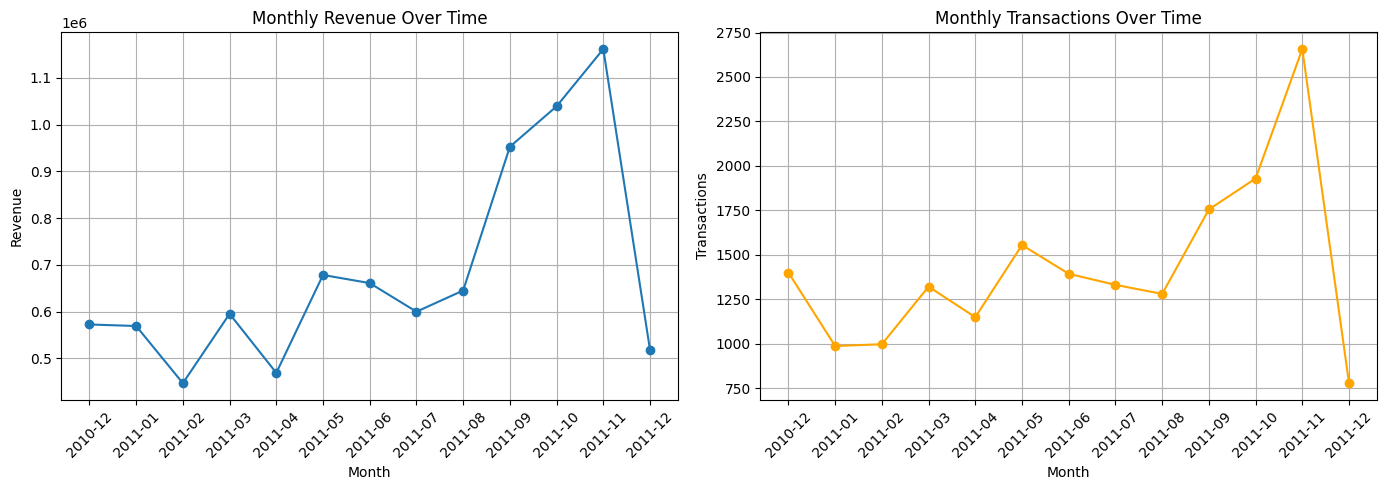

In [ ]:
# Plotting monthly revenue
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(monthly_data['InvoiceDate'], monthly_data['Revenue'], marker='o')
plt.title('Monthly Revenue Over Time')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(monthly_data['InvoiceDate'], monthly_data['Total Transactions'], marker='o', color='orange')
plt.title('Monthly Transactions Over Time')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

The visualizations reveals that both plots indicate similar trends, with notable increases in revenue and transactions between September 2011 and November 2011, peaking in November. The revenue surpasses 1.4 million, and transactions peak at approximately 2,750 in November, signifying a strong correlation between the two metrics. However, December 2011 shows a sharp drop in both revenue and transactions, with revenue falling below 0.5 million and transactions dropping to fewer than 750, highlighting an anomaly. This sudden decline might reflect seasonal trends, operational changes, or external factors, such as the conclusion of a promotional event or reduced consumer activity. Despite some fluctuations in earlier months, both metrics exhibit a stable pattern until mid-2011, followed by a rapid growth phase. The alignment of peaks and drops across the plots strongly suggests that revenue is heavily influenced by transaction volume.

# Average Order Value

In [ ]:
# Calculating Average Order Value (AOV) for each month
monthly_data['AverageOrderValue'] = monthly_data['Revenue'] / monthly_data['Total Transactions']
#displaying the monthly transactions, average value order and revenue
monthly_data

,InvoiceDate,Revenue,Total Transactions,AverageOrderValue
0,2010-12,572713.890,1400,409.081350
1,2011-01,569445.040,987,576.945329
2,2011-02,447137.350,997,448.482798
3,2011-03,595500.760,1321,450.795428
4,2011-04,469200.361,1149,408.355406
5,2011-05,678594.560,1555,436.395215
6,2011-06,661213.690,1393,474.668837
7,2011-07,600091.011,1331,450.857258
8,2011-08,645343.900,1280,504.174922
9,2011-09,952838.382,1755,542.927853


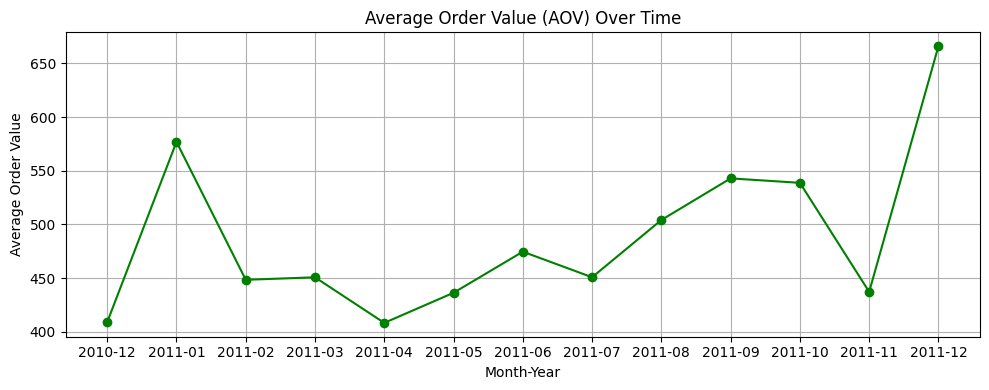

In [ ]:
# Plot Average Order Value over time
plt.figure(figsize=(10, 4))
plt.plot(monthly_data['InvoiceDate'], monthly_data['AverageOrderValue'], marker='o', color='green')
plt.title('Average Order Value (AOV) Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Average Order Value')
plt.grid(True)
plt.tight_layout()
plt.show()

Displaying the Monthly Transactions, Average Value order and Total Revenue

Average order value [AOV] fluctuated significantly throughout the year. January and December saw AOV spikes [over $600] likely due to promotions/holiday spending on premium items. February and November experienced dips [around $400] potentially from post-holiday normalization and promotional discounting, respectively. A period of steady AOV growth occurred between June and October. High transaction volume periods [e.g., November] correlated with lower AOV, suggesting a focus on volume over individual order value during promotions.



## Detecting Outliers using Z Score


In [ ]:
from scipy.stats import zscore
#Total Revenue
monthly_data['zscore_revenue'] = zscore(monthly_data['Revenue'])
anomalies = monthly_data[monthly_data['zscore_revenue'].abs() > 2]
print("Anomalies in Revenue:")
print(anomalies)

#average order value
monthly_data['zscore_aov'] = zscore(monthly_data['AverageOrderValue'])
anomalies_aov = monthly_data[monthly_data['zscore_aov'].abs() > 2]
print("\nAnomalies in Average Order Value:")
print(anomalies_aov)

#Total transactions
monthly_data['zscore_transactions'] = zscore(monthly_data['Total Transactions'])
anomalies_transactions = monthly_data[monthly_data['zscore_transactions'].abs() > 2]


Anomalies in Revenue:
   InvoiceDate     Revenue  Total Transactions  AverageOrderValue  \
11     2011-11  1161817.38                2657         437.266609   

    zscore_revenue  
11        2.219087  

Anomalies in Average Order Value:
   InvoiceDate    Revenue  Total Transactions  AverageOrderValue  \
12     2011-12  518192.79                 778         666.057571   

    zscore_revenue  zscore_aov  
12       -0.779413    2.464994  


# Detecting Outliers using IQR



In [ ]:
# IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Find anomalies in Total Revenue using IQR
revenue_outliers_iqr = detect_outliers_iqr(monthly_data, 'Revenue')
print("\nRevenue Anomalies (IQR):")
print(revenue_outliers_iqr)

# Find anomalies in Total Transactions using IQR
# The column name was changed to 'Total Transactions'
transactions_outliers_iqr = detect_outliers_iqr(monthly_data, 'Total Transactions')
print("\nTotal Transactions Anomalies (IQR):")
transactions_outliers_iqr


Revenue Anomalies (IQR):
   InvoiceDate      Revenue  Total Transactions  AverageOrderValue  \
9      2011-09   952838.382                1755         542.927853   
10     2011-10  1039318.790                1929         538.786309   
11     2011-11  1161817.380                2657         437.266609   

    zscore_revenue  zscore_aov  zscore_transactions  
9         1.245501    0.759825             0.708664  
10        1.648394    0.702470             1.082934  
11        2.219087   -0.703431             2.648846  

Total Transactions Anomalies (IQR):


,InvoiceDate,Revenue,Total Transactions,AverageOrderValue,zscore_revenue,zscore_aov,zscore_transactions
11,2011-11,1161817.38,2657,437.266609,2.219087,-0.703431,2.648846


# Total Revenue Anomalies

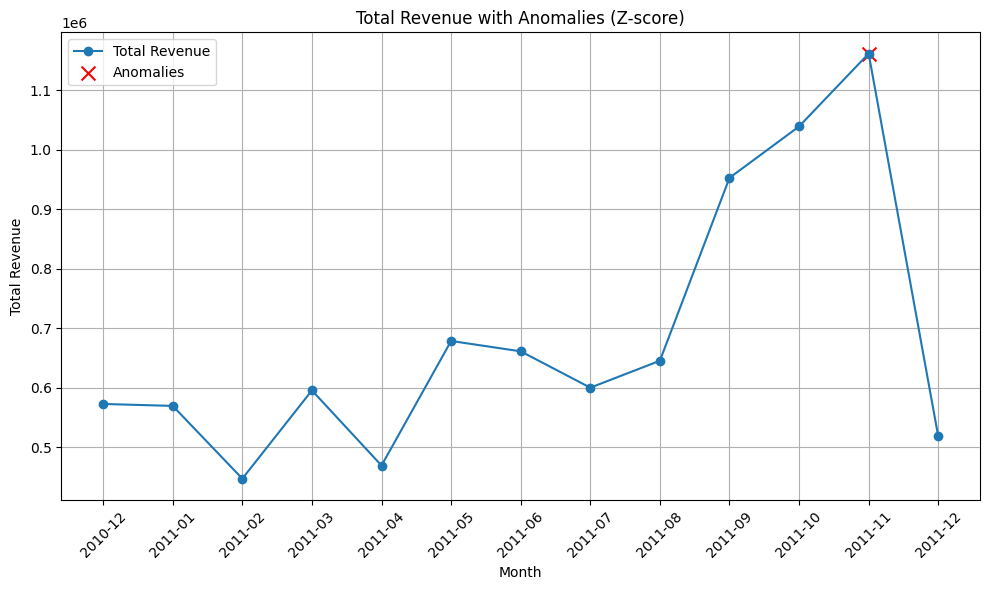

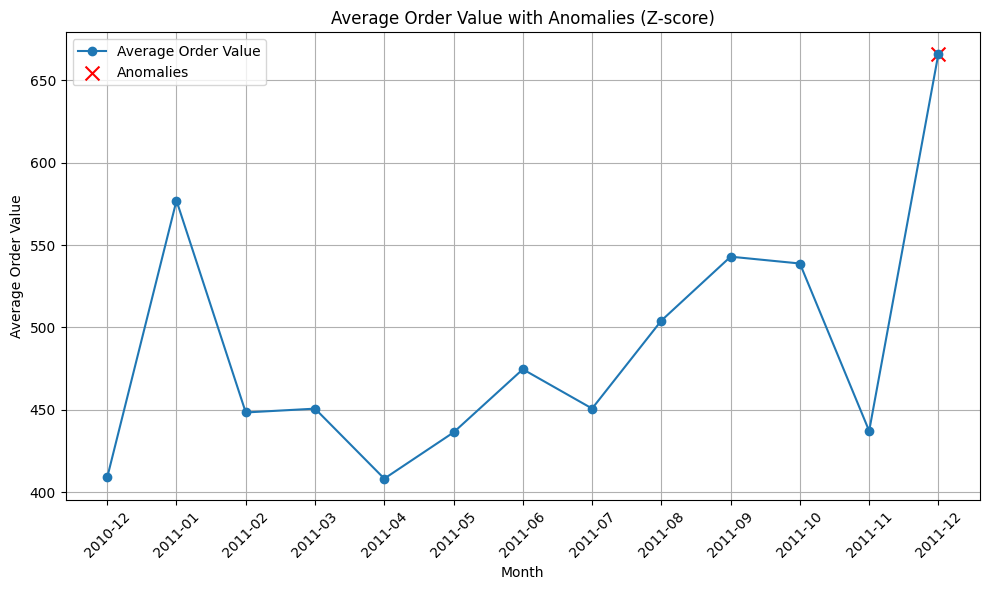

In [ ]:
# Plot for Total Revenue Anomalies
plt.figure(figsize=(10, 6))
plt.plot(monthly_data['InvoiceDate'], monthly_data['Revenue'], label='Total Revenue', marker='o')
plt.scatter(monthly_data['InvoiceDate'][monthly_data['zscore_revenue'].abs() > 2],
            monthly_data['Revenue'][monthly_data['zscore_revenue'].abs() > 2],
            color='red', label='Anomalies', marker='x', s=100)  # Highlight anomalies
plt.title('Total Revenue with Anomalies (Z-score)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot for Average Order Value Anomalies
plt.figure(figsize=(10, 6))
plt.plot(monthly_data['InvoiceDate'], monthly_data['AverageOrderValue'], label='Average Order Value', marker='o')
plt.scatter(monthly_data['InvoiceDate'][monthly_data['zscore_aov'].abs() > 2],
            monthly_data['AverageOrderValue'][monthly_data['zscore_aov'].abs() > 2],
            color='red', label='Anomalies', marker='x', s=100)
plt.title('Average Order Value with Anomalies (Z-score)')
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Revenue was stable until mid-2011, then peaked in October 2011 (over $1.1M)
before sharply declining in November/December. Average order value (AOV) peaked in January and December (over $550 and $650, respectively) and declined in March/April and November. The company should replicate October's success, address the November/December decline, and leverage high-AOV periods with premium product promotion while using targeted campaigns during low-AOV periods.

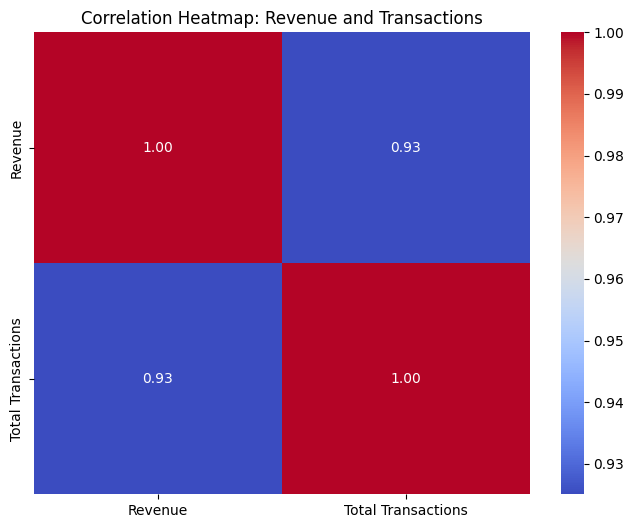

In [ ]:
#plotting the correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = monthly_data[['Revenue', 'Total Transactions']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Revenue and Transactions')
plt.show()

# Column Engineering

In [ ]:
def categorize_description(description):
    """
    Categorizes product descriptions into broader categories based on keywords and content.

    """
    description = description.lower()

    # Expanded keyword lists and refined logic
    if any(keyword in description for keyword in ["set", "gift", "bundle", "pack"]):
        return "Gift Sets & Bundles"
    elif any(keyword in description for keyword in ["box", "crate", "storage", "container"]):
        return "Boxes & Crates"
    elif any(keyword in description for keyword in ["paper", "card", "stationery", "envelope", "notebook", "pen", "pencil"]):
        return "Stationery & Cards"
    elif any(keyword in description for keyword in ["candle", "scented", "wax", "fragrance", "aroma"]):
        return "Candles & Scents"
    elif any(keyword in description for keyword in ["decoration", "christmas", "holiday", "ornament", "festive", "easter", "halloween"]):
        return "Holiday & Christmas Decorations"
    elif any(keyword in description for keyword in ["kitchen", "cook", "utensil", "appliance", "bake", "food prep", "dining"]):
        return "Kitchen Items & Appliances"
    elif any(keyword in description for keyword in ["toy", "game", "puzzle", "play", "children", "kids", "doll", "plush"]):
        return "Toys, Games & Puzzles"
    elif any(keyword in description for keyword in ["jewelry", "jewellery", "necklace", "bracelet", "ring", "earring", "pendant", "accessory"]):
        return "Jewelry & Accessories"
    elif any(keyword in description for keyword in ["mug", "cup", "tea", "coffee", "drinkware", "glass", "bottle"]):
        return "Drinkware & Mugs"
    elif any(keyword in description for keyword in ["vintage", "retro", "antique", "classic", "old", "collectible"]):
        return "Vintage & Retro Items"
    elif any(keyword in description for keyword in ["bag", "purse", "backpack", "handbag", "tote", "wallet", "luggage"]):
        return "Bags & Accessories"
    elif any(keyword in description for keyword in ["art", "painting", "drawing", "print", "sculpture", "canvas", "craft", "hobby"]):
        return "Art & Collectibles"
    elif any(keyword in description for keyword in ["furniture", "couch", "chair", "table", "sofa", "bed", "desk", "home decor"]):
        return "Furniture & Home Decor"
    elif any(keyword in description for keyword in ["clothing", "shirt", "dress", "jeans", "pants", "skirt", "jacket", "apparel"]):
        return "Clothing & Apparel"
    elif any(keyword in description for keyword in ["shoes", "sneakers", "boots", "sandals", "footwear", "slippers"]):
        return "Footwear & Shoes"
    elif any(keyword in description for keyword in ["beauty", "makeup", "cosmetic", "skincare", "haircare", "fragrance", "perfume"]):
        return "Beauty & Cosmetics"
    elif any(keyword in description for keyword in ["book", "novel", "literature", "magazine", "comic", "reading", "journal"]):
        return "Books & Literature"
    elif any(keyword in description for keyword in ["electronics", "phone", "laptop", "computer", "gadget", "device", "charger", "cable"]):
        return "Electronics & Gadgets"
    elif any(keyword in description for keyword in ["sport", "gym", "equipment", "fitness", "exercise", "yoga", "training", "outdoor"]):
        return "Sports & Fitness"
    elif any(keyword in description for keyword in ["food", "snack", "drink", "beverage", "chocolate", "candy", "tea", "coffee"]):
        return "Food & Beverages"



    else:
        return "Uncategorized"

df['Category'] = df['Description'].apply(categorize_description)

In [ ]:
#checking the counts of the categories
df['Category'].value_counts()

,count
Category,
Uncategorized,101930
Gift Sets & Bundles,63482
Vintage & Retro Items,40081
Drinkware & Mugs,30964
Art & Collectibles,27594
Stationery & Cards,27145
Holiday & Christmas Decorations,24654
Bags & Accessories,22495
Boxes & Crates,21059


Table showing product categories that have been grouped into high, medium, and low performers. Top categories included Gift Sets & Bundles, Vintage & Retro Items, and Drinkware & Mugs, driven by gifting, niche appeal, and everyday use, respectively. Middle performers like Toys, Games & Puzzles and Kitchen Items & Appliances showed moderate interest. Low-performing categories such as Books & Literature and Electronics & Gadgets had minimal demand or representation. A significant number of products (101,930) remained uncategorized.

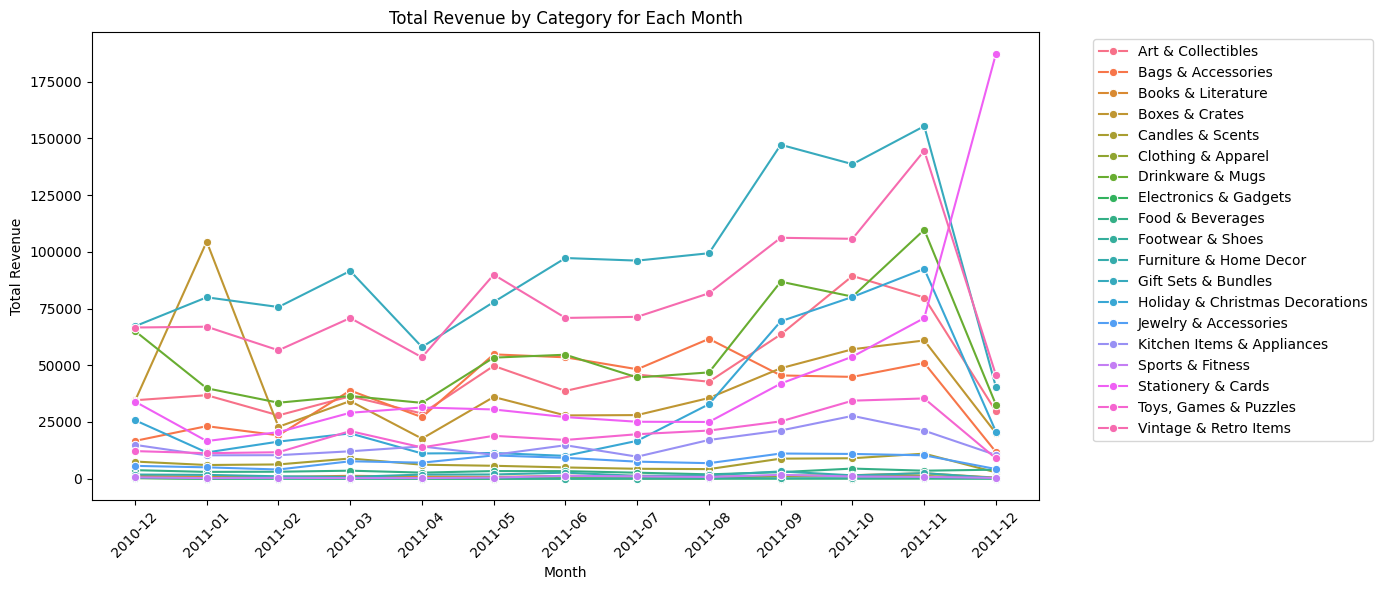


Note: The 'Uncategorized' category was removed from the plot because it represents items that could not be categorized into specific product groups.


In [ ]:
# Grouping by month and category, then sum the revenue
category_revenue = df.groupby([df['InvoiceDate'].dt.to_period('M'), 'Category'])['Revenue'].sum().reset_index()

# Converting 'InvoiceDate' to string for plotting (Seaborn compatibility)
category_revenue['InvoiceDate'] = category_revenue['InvoiceDate'].dt.strftime('%Y-%m')  # Convert Period to string

# Filtering out 'Uncategorized' category
filtered_category_revenue = category_revenue[category_revenue['Category'] != 'Uncategorized']

# Plotting
plt.figure(figsize=(14, 6))
sns.lineplot(x='InvoiceDate', y='Revenue', hue='Category', data=filtered_category_revenue, marker='o')
plt.title('Total Revenue by Category for Each Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # To Move the legend outside the plot
plt.tight_layout()
plt.show()


# Printing an explanation for removing 'Uncategorized'
print("\nNote: The 'Uncategorized' category was removed from the plot because it represents items that could not be categorized into specific product groups.")

From the chart, Vintage & Retro Items and Gift Sets & Bundles consistently generated the highest revenue, with the latter performing exceptionally well during holidays. Toys, Games & Puzzles, Kitchen Items & Appliances, Art & Collectibles, and Stationery & Cards showed consistent growth trends. Holiday & Christmas Decorations and Gift Sets & Bundles also saw sustained revenue increases, particularly during holiday seasons, along with Vintage & Retro Items and Bags & Accessories demonstrating stable growth.

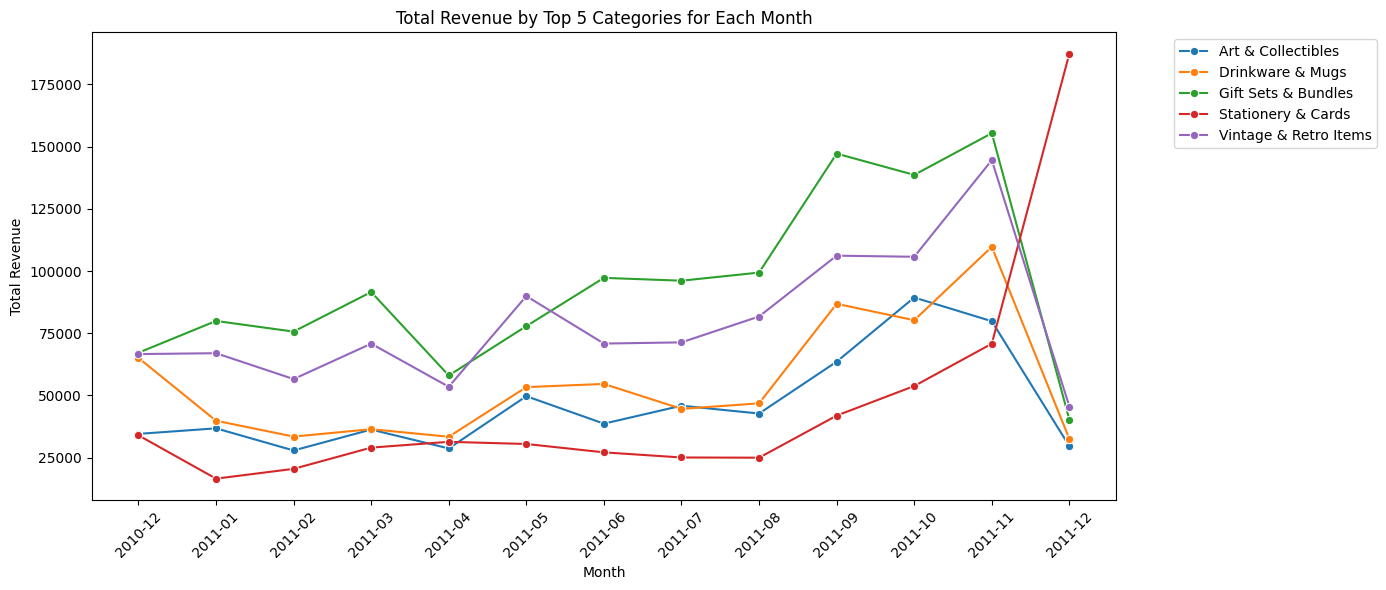

In [ ]:
# Getting the  the top 5 categories by total revenue, excluding "Uncategorized"
top_5_categories = df[df['Category'] != 'Uncategorized'].groupby('Category')['Revenue'].sum().nlargest(5).index.tolist()

# Group by month and category, then sum the revenue
category_revenue = df[df['Category'].isin(top_5_categories)].groupby([df['InvoiceDate'].dt.to_period('M'), 'Category'])['Revenue'].sum().reset_index()

# Convert 'InvoiceDate' to string for plotting (Seaborn compatibility)
category_revenue['InvoiceDate'] = category_revenue['InvoiceDate'].dt.strftime('%Y-%m')  # Convert Period to string

# Plotting
plt.figure(figsize=(14, 6))
sns.lineplot(x='InvoiceDate', y='Revenue', hue='Category', data=category_revenue, marker='o')
plt.title('Total Revenue by Top 5 Categories for Each Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  #To Move the legend outside the plot
plt.tight_layout()
plt.show()

From the chart, Several product categories saw peak performance in November 2011, followed by December declines: Gift Sets & Bundles, Vintage & Retro Items, Drinkware & Mugs, and Art & Collectibles, likely due to early Christmas shopping followed by market saturation or inventory issues. Stationery & Cards peaked in December, aligning with holiday card-giving. Opportunities exist to improve December sales through inventory management, new product introductions, targeted promotions, and partnerships.

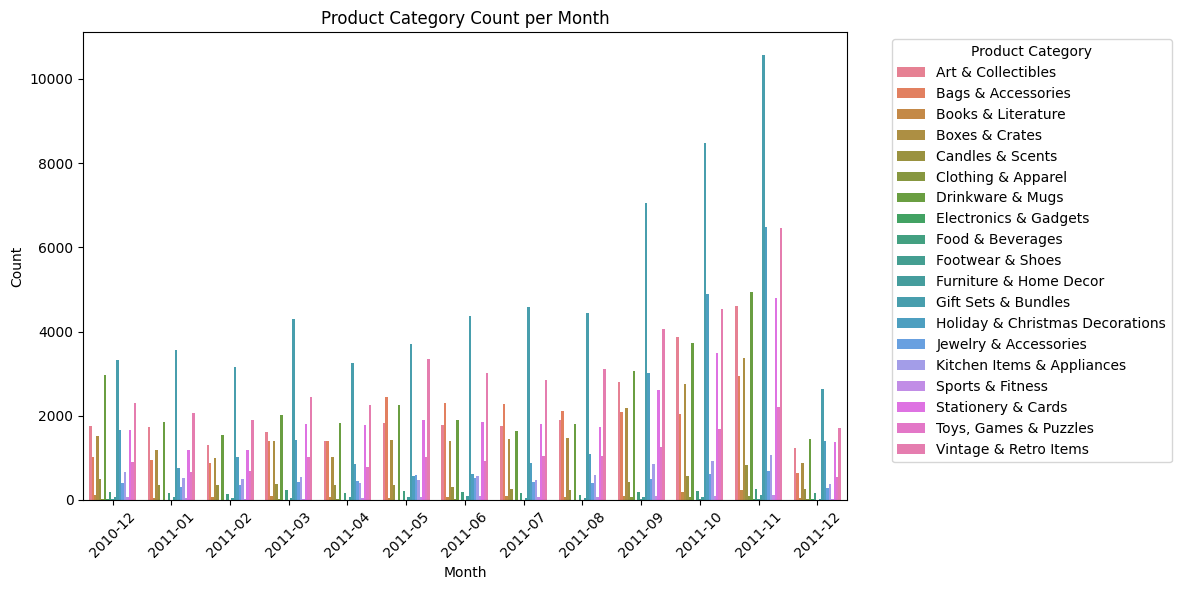

In [ ]:

# Plotting the count of each product category per month, excluding 'Uncategorized'
plt.figure(figsize=(12, 6))
category_counts = df[df['Category'] != 'Uncategorized'].groupby([df['InvoiceDate'].dt.to_period('M'), 'Category']).size().reset_index(name='counts')
sns.barplot(x='InvoiceDate', y='counts', hue='Category', data=category_counts)
plt.title('Product Category Count per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

From the chart, Several product categories show seasonal sales fluctuations, primarily peaking in October, November, and/or December due to holidays and gift-giving. Vintage & Retro Items, Holiday & Christmas Decorations, Toys, Games & Puzzles, Clothing & Apparel, Electronics & Gadgets, Kitchen Items & Appliances, Gift Sets & Bundles, Books & Literature, and Furniture & Home Decor all exhibit this trend. Sports & Fitness sees a slight January peak related to New Year's resolutions. Drinkware & Mugs and Art & Collectibles show more consistent demand with slight year-end increases. Recommendations include adjusting stock levels, targeted marketing campaigns, special promotions, and product bundling.

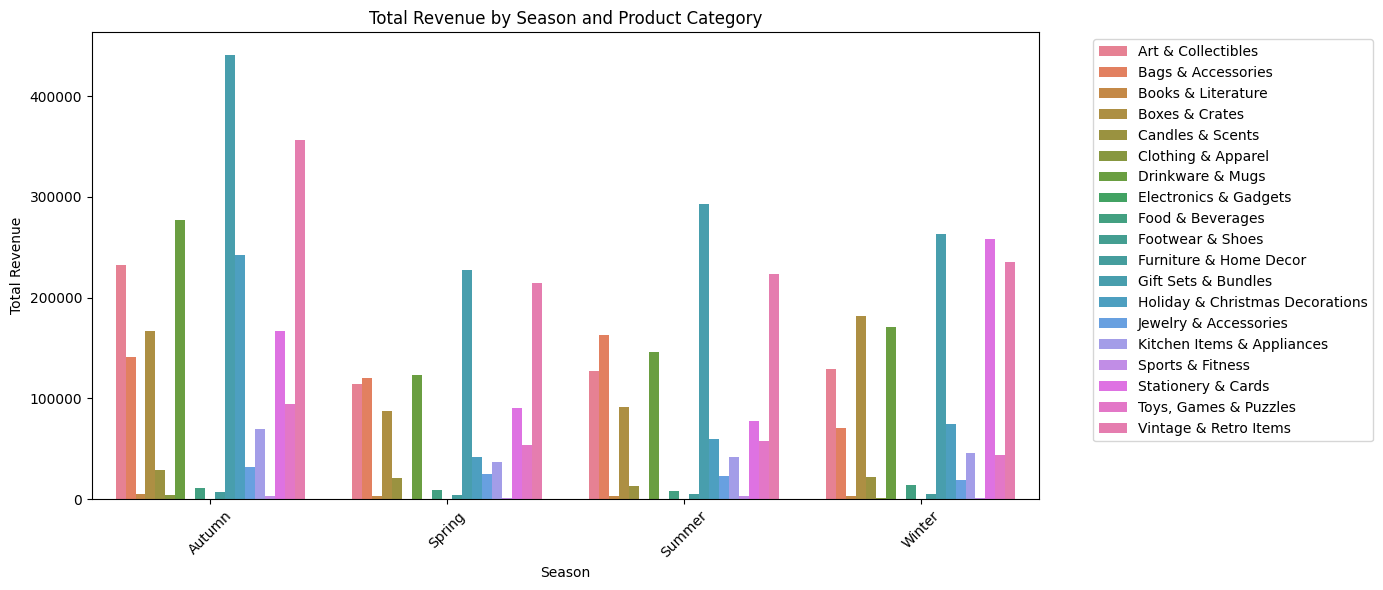

In [ ]:
# Define a function to determine the season
def get_season(date):
    month = date.month
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

df['Season'] = df['InvoiceDate'].apply(get_season)


# Group data by season and category to calculate total revenue
seasonal_category_revenue = df.groupby(['Season', 'Category'])['Revenue'].sum().reset_index()


# Filter out 'Uncategorized' for better visualization
seasonal_category_revenue = seasonal_category_revenue[seasonal_category_revenue['Category'] != 'Uncategorized']

# Create the plot
plt.figure(figsize=(14, 6))
sns.barplot(x='Season', y='Revenue', hue='Category', data=seasonal_category_revenue)
plt.title('Total Revenue by Season and Product Category')
plt.xlabel('Season')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight drawn from this revealed that in the season of Autumn, revenue is driven by Electronics & Gadgets and Toys, Games & Puzzles, with moderate performance from holiday preparation categories. Winter sees peak revenue for Holiday & Christmas Decorations and Gift Sets & Bundles, with moderate performance from holiday-related categories. Spring revenue is led by Vintage & Retro Items and Bags & Accessories, with steady performance from lifestyle categories. Summer revenue peaks for Clothing & Apparel and Sports & Fitness, with moderate performance from outdoor-related categories. Marketing and inventory strategies should align with these seasonal trends.

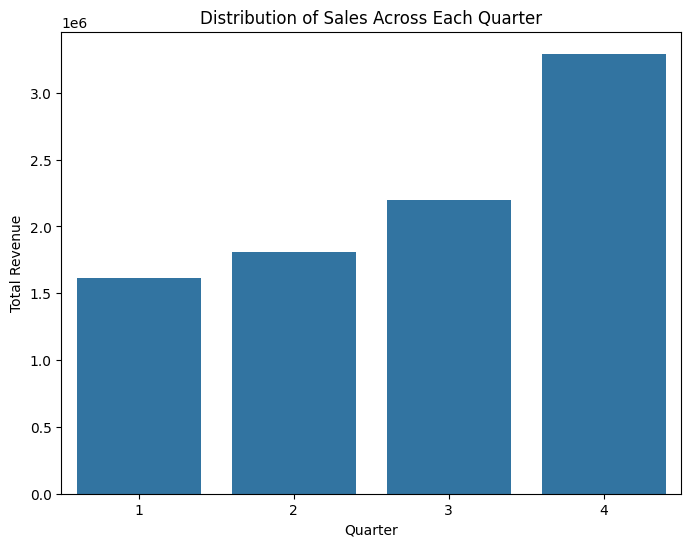

In [ ]:
# Extracting quarter from the 'InvoiceDate' column
df['Quarter'] = df['InvoiceDate'].dt.quarter

# Grouping by quarter and summing the revenue
quarterly_sales = df.groupby('Quarter')['Revenue'].sum().reset_index()

# Plotting the distribution of sales across each quarter
plt.figure(figsize=(8, 6))
sns.barplot(x='Quarter', y='Revenue', data=quarterly_sales)
plt.title('Distribution of Sales Across Each Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue')
plt.show()

Total revenue shows a consistent upward trend across all four quarters, with the fourth quarter exhibiting the highest sales volume, significantly outpacing the other quarters.

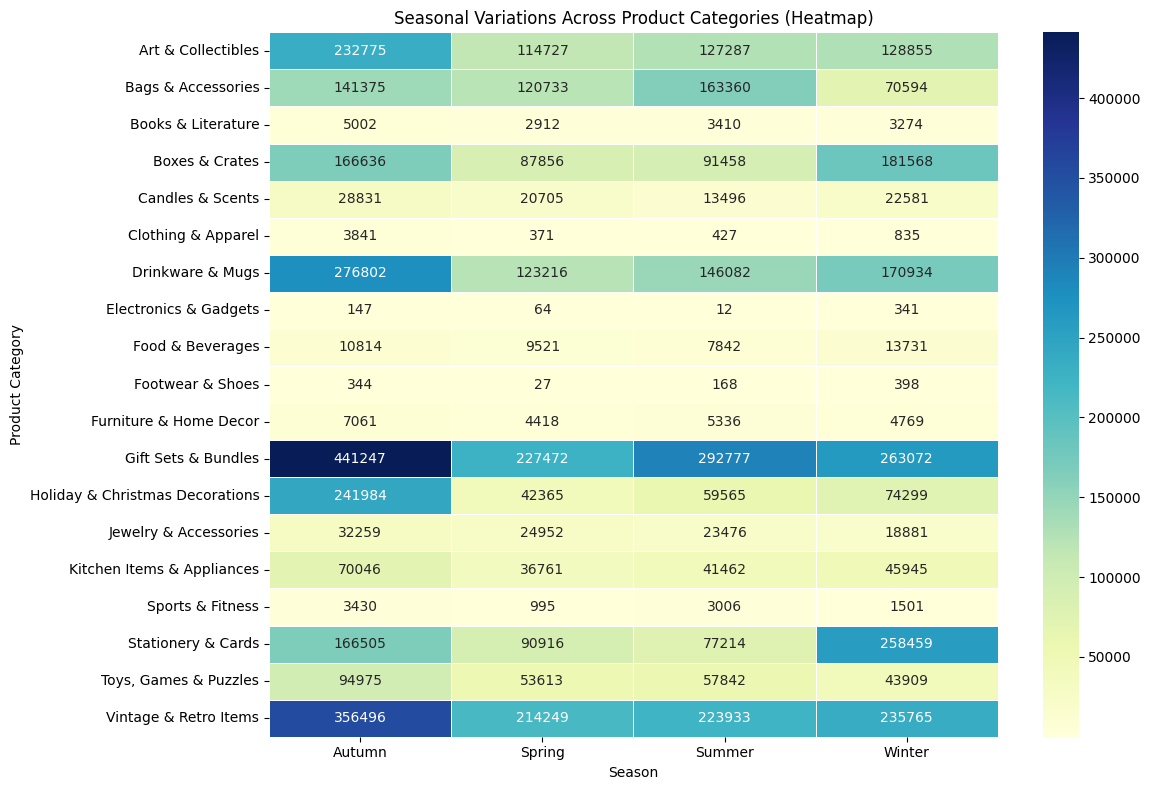

In [ ]:
# Creating the heatmap for the Seasonal variations
plt.figure(figsize=(12, 8))
heatmap_data = seasonal_category_revenue.pivot_table(index='Category', columns='Season', values='Revenue')
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Seasonal Variations Across Product Categories (Heatmap)')
plt.xlabel('Season')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

# Analysing Customer Purchase Behaviour

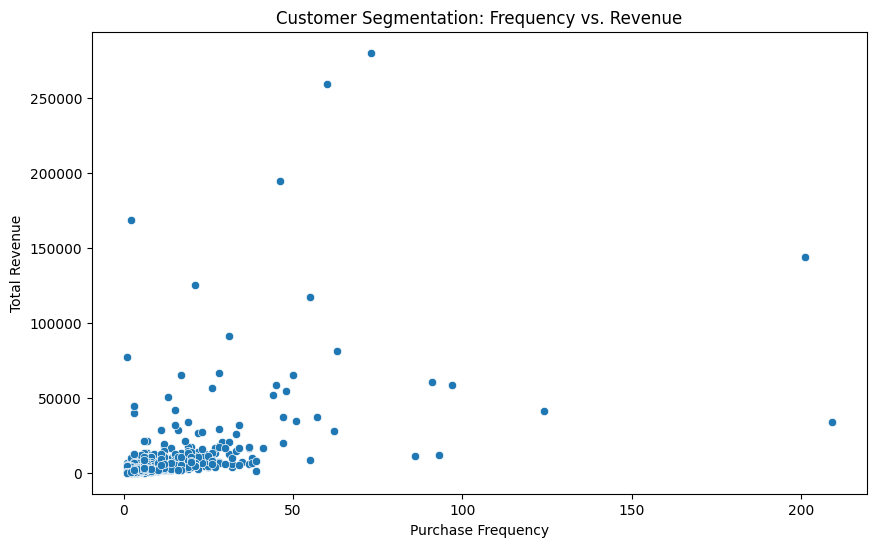

In [ ]:
customer_segments = df.groupby('CustomerID').agg({'InvoiceNo': 'nunique', 'Revenue': 'sum'})


customer_segments = customer_segments.rename(columns={
    'InvoiceNo': 'Frequency'
})


# Visualizing customer segments using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_segments, x='Frequency', y='Revenue')
plt.title('Customer Segmentation: Frequency vs. Revenue')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Revenue')
plt.show()

The customer segmentation analysis reveals distinct purchasing behaviors. A key segment consists of low-frequency, high-revenue customers who contribute significantly to total revenue, likely through large purchases, highlighting their importance for targeted retention strategies. Another dense cluster comprises low-frequency, low-revenue customers, representing occasional shoppers who may benefit from incentives to increase their purchase frequency or basket size. Frequent purchasers with moderate revenue suggest an opportunity for upselling or cross-selling, as they tend to make smaller, more frequent transactions. Additionally, outliers with exceptionally high revenue or frequency represent VIP customers who may warrant personalized loyalty programs. These insights provide a foundation for tailored marketing strategies to enhance revenue and customer retention.








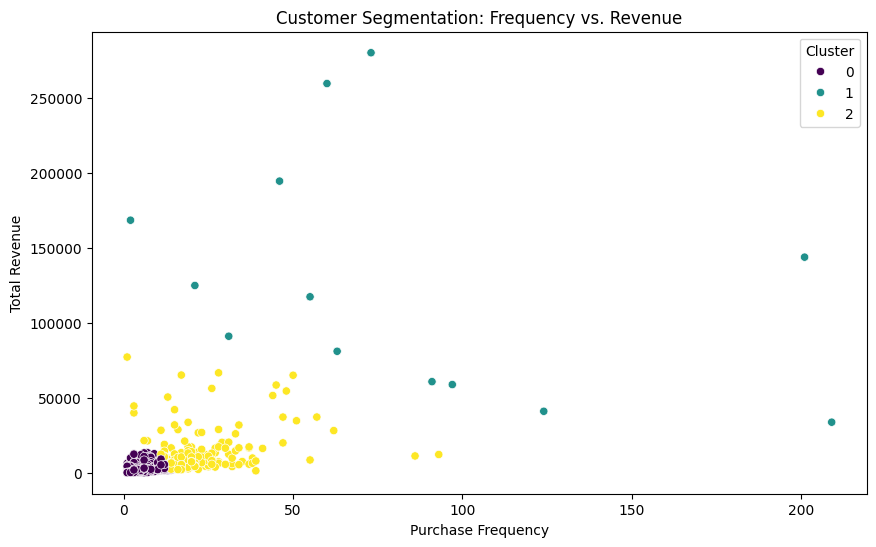

In [ ]:
#using K-means to identify the clusters to effectivley classify the customers
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X = customer_segments[['Frequency', 'Revenue']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Specify 3 clusters
customer_segments['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_segments, x='Frequency', y='Revenue', hue='Cluster', palette='viridis')
plt.title('Customer Segmentation: Frequency vs. Revenue')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Revenue')
plt.show()

Customer segmentation based on purchase frequency and total revenue revealed three clusters: Cluster 0 (low frequency/low revenue), likely new or occasional shoppers, requiring engagement strategies; Cluster 1 (moderate frequency/moderate revenue), regular customers targeted for upselling/cross-selling; and Cluster 2 (high frequency/high revenue), high-value customers prioritized for retention through exclusive offers and enhanced service.